In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from math import sqrt

# Análise de estatística descritiva 

## Datset (D1): _Titanic_

In [2]:
df_titanic = pd.read_csv(
    'data\\titanic.csv'
)
var_qual_nom = ["Name", "Sex", "Survived"]
var_qual_ord = ["Pclass"]
var_quant_disc = ['Siblings/Spouses Aboard', 'Parents/Children Aboard']
var_quant_cont = ['Age', 'Fare']

### Identificando Variáveis **Quantitativas** e **Qualitativas**

In [3]:
pd.DataFrame({
    "Coluna": [col for col in df_titanic.columns],
    "Tipo de Variavel": [
        "Variável Qualitativa Nominal" if col in var_qual_nom else 
        "Variável Qualitativa Ordinal" if col in var_qual_ord else
        "Variável Quantitativa Discreta" if col in var_quant_disc else
        "Variável Quantitativa Contínua" 
        for col in df_titanic.columns 
        ],
    "Exemplos de valores": [df_titanic[col].sample(10).tolist() for col in df_titanic.columns]
})

,Coluna,Tipo de Variavel,Exemplos de valores
0,Survived,Variável Qualitativa Nominal,"[0, 0, 1, 1, 1, 0, 0, 1, 1, 0]"
1,Pclass,Variável Qualitativa Ordinal,"[3, 1, 1, 3, 3, 3, 2, 1, 1, 3]"
2,Name,Variável Qualitativa Nominal,"[Miss. Bridget Mary O'Sullivan, Master. Willia..."
3,Sex,Variável Qualitativa Nominal,"[male, female, female, female, male, male, fem..."
4,Age,Variável Quantitativa Contínua,"[20.0, 28.0, 21.0, 18.0, 33.0, 42.0, 19.0, 17...."
5,Siblings/Spouses Aboard,Variável Quantitativa Discreta,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 1]"
6,Parents/Children Aboard,Variável Quantitativa Discreta,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
7,Fare,Variável Quantitativa Contínua,"[7.8958, 9.2167, 52.0, 26.25, 10.4625, 7.125, ..."


Cada variável foi definida principalmente com base em seus valores, sendo classificadas como numéricas ou textuais, com exceção da coluna Survived, que, embora apresente valores numéricos, possui a representação de uma variável nominal.

---
### Gráficos relacionados as colunas: `Sex`, `Pclass`, `Survived`

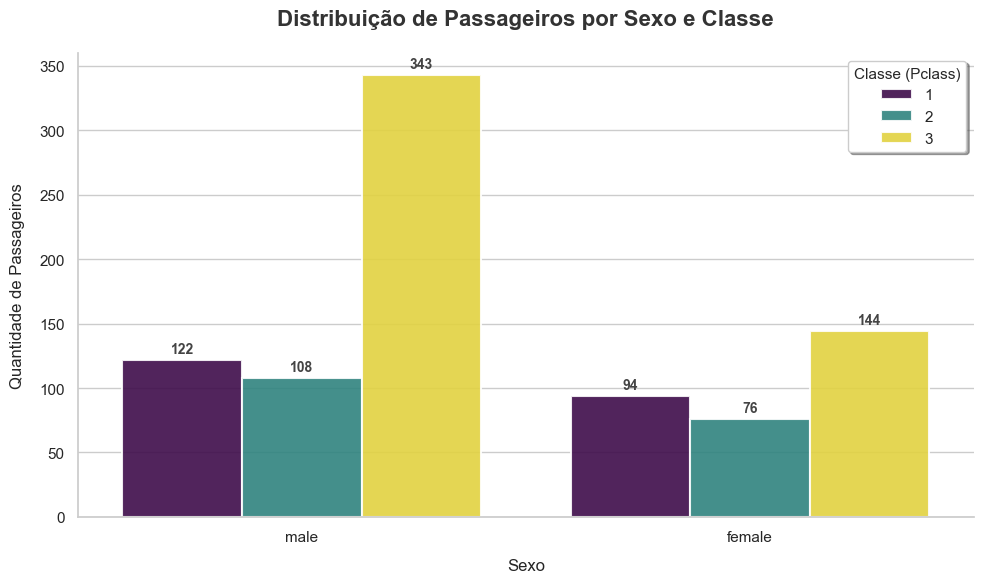

In [4]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['font.family'] = 'sans-serif'

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_titanic, 
    x='Sex', 
    hue='Pclass', 
    palette='viridis',
    alpha=0.9,
    edgecolor='white',
    linewidth=1.5
)

plt.title('Distribuição de Passageiros por Sexo e Classe', fontsize=16, pad=20, fontweight='bold', color='#333333')
plt.xlabel('Sexo', fontsize=12, labelpad=10)
plt.ylabel('Quantidade de Passageiros', fontsize=12, labelpad=10)

for container in ax.containers:
    ax.bar_label(
        container, 
        padding=3, 
        fontsize=10, 
        fontweight='bold', 
        color='#444444'
    )

plt.legend(title='Classe (Pclass)', title_fontsize='11', loc='upper right', frameon=True, shadow=True)

sns.despine()
plt.tight_layout()
plt.show()

Observa-se que a maior concentração de passageiros está na 3ª classe, tanto para homens quanto para mulheres, com predominância do sexo masculino. Já a 1ª e a 2ª classes apresentam menor número de passageiros em comparação com a 3ª classe, indicando que a maioria dos passageiros pertencia a classes socioeconômicas mais baixas.

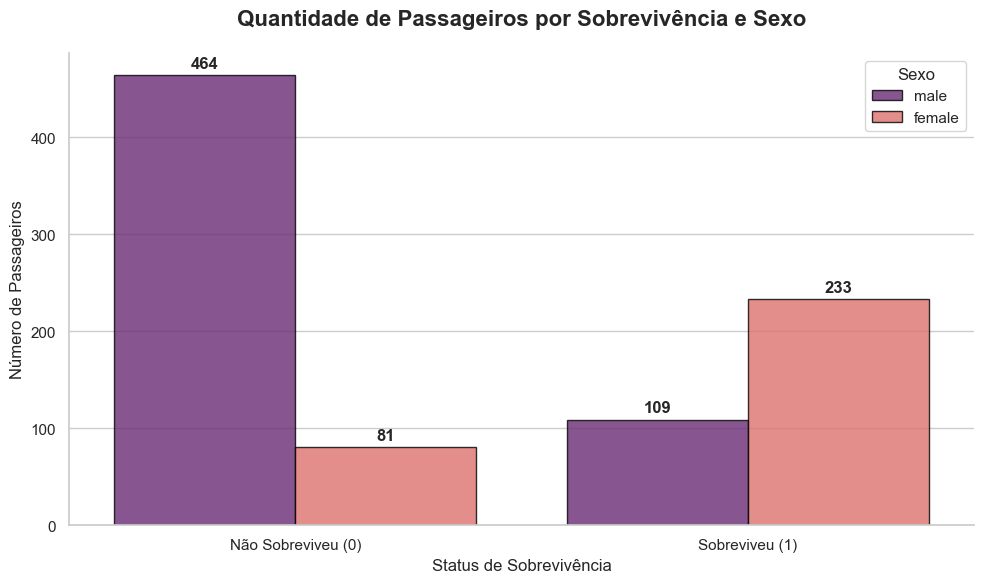

In [5]:
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_titanic, 
    x='Survived', 
    hue='Sex', 
    palette='magma',
    alpha=0.8,
    edgecolor='black'
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Não Sobreviveu (0)', 'Sobreviveu (1)'])

plt.title('Quantidade de Passageiros por Sobrevivência e Sexo', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Número de Passageiros', fontsize=12)
plt.xlabel('Status de Sobrevivência', fontsize=12)
plt.legend(title='Sexo')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

Nota-se a predominância de sobreviventes do sexo feminino em relação ao sexo masculino. Esse comportamento pode ser justificado pelas normas de evacuação da época, que priorizavam mulheres e crianças. Em contrapartida, verifica-se uma elevada quantidade de óbitos entre os passageiros do sexo masculino.

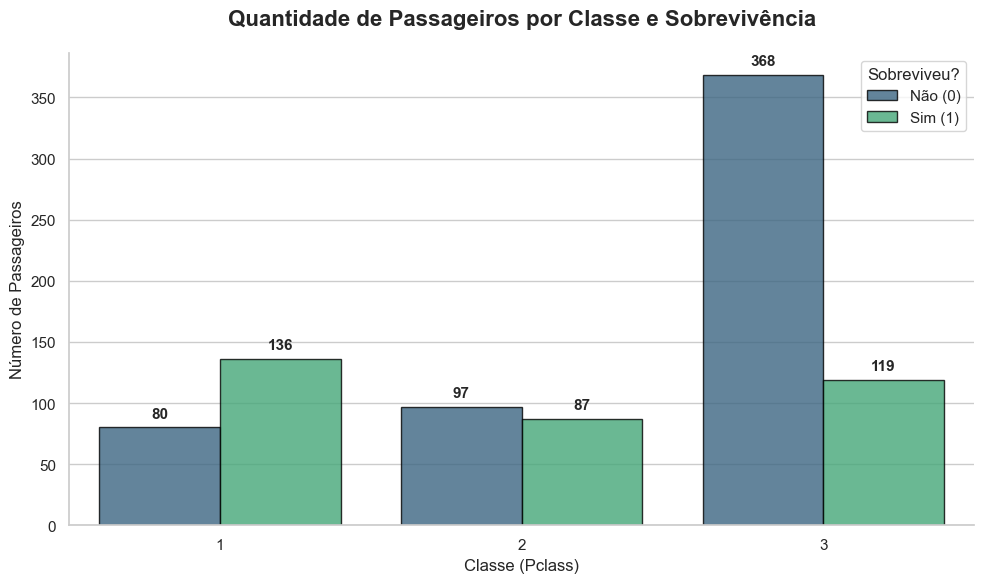

In [6]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_titanic, 
    x='Pclass', 
    hue='Survived',
    palette='viridis',
    edgecolor='black',
    alpha=0.8
)

plt.title('Quantidade de Passageiros por Classe e Sobrevivência', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Número de Passageiros', fontsize=12)
plt.xlabel('Classe (Pclass)', fontsize=12)
plt.legend(title='Sobreviveu?', labels=['Não (0)', 'Sim (1)'])

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontweight='bold', fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

A possível priorização dos passageiros da 1ª classe nos procedimentos de evacuação pode justificar o fato de que, apesar de não concentrar o maior número de indivíduos, essa classe apresenta a maior taxa de sobrevivência em relação às demais.

---
### Análise das medidas de tendência central das colunas: `Age` e `Fare`

In [7]:
stats_age = df_titanic['Age'].describe()
stats_age['90%'] = df_titanic['Age'].quantile(.9)
stats_age['10%'] = df_titanic['Age'].quantile(.1)
stats_age = stats_age.rename({'50%': 'median', '25%': 'q1', '75%': 'q3'})
stats_age = stats_age.to_frame()

stats_fare = df_titanic['Fare'].describe()
stats_fare['90%'] = df_titanic['Fare'].quantile(.9)
stats_fare['10%'] = df_titanic['Fare'].quantile(.1)
stats_fare = stats_fare.rename({'50%': 'median', '25%': 'q1', '75%': 'q3'})
stats_fare = stats_fare.to_frame()

df_stats_fare_age = pd.concat([stats_age, stats_fare], axis=1)
df_stats_fare_age.T[['mean', 'median','std', 'min','10%', 'q1', 'q3', '90%', 'max']]

,mean,median,std,min,10%,q1,q3,90%,max
Age,29.471443,28.0000,14.121908,0.42,14.80,20.250,38.0000,49.0000,80.0000
Fare,32.305420,14.4542,49.782040,0.00,7.55,7.925,31.1375,77.9583,512.3292


_Para **Age**:_
- Observa-se a presença de passageiros de todas as faixas etárias, incluindo recém-nascidos (idade mínima de aproximadamente 0,42 anos) e idosos (idade máxima de 80 anos), indicando que havia pessoas de diferentes idades a bordo.

_Para **Fare**:_
- Considerando que a tarifa mínima registrada é 0, é possível que existam passageiros que não pagaram pela passagem, o que pode estar relacionado a tripulantes, passageiros beneficiados por gratuidade ou registros incompletos, não necessariamente embarques ilegais.

---
### Correlação entr: `Age` e `Fare`

In [8]:
df_titanic[['Age', 'Fare']].corr()

,Age,Fare
Age,1.000000,0.112329
Fare,0.112329,1.000000


É notória a relação existente entre `Age` e `Fare` é positiva mostrando que as duas variáveis aumentam ou diminuem juntas, movendo-se na mesma direção, entretanto essa correlação não apresenta ter uma grande representatividade.

### Datset (D2): _Eleições_

In [9]:
df_elections = pd.read_csv('data\\eleicoes.csv')
df_elections.columns = df_elections.columns.str.strip()
df_elections['State'] = df_elections['State'].str.strip()
df_elections

,State,Candidate Number,Money (R$ Reais),Votes
0,AC,1919,35504.34,515
1,AC,1212,397136.76,11397
2,AC,5012,1580.00,15
3,AC,1321,66093.33,1913
4,AC,1144,296327.21,13610
...,...,...,...,...
6348,SP,7749,136167.91,375
6349,SP,4581,600.00,337
6350,SP,5566,1341287.21,79909
6351,SP,3199,9849.94,1085


In [10]:
SELECTED_STATES = ['CE', 'BA', 'PE']

---
### Histogramas do número de votos por estado

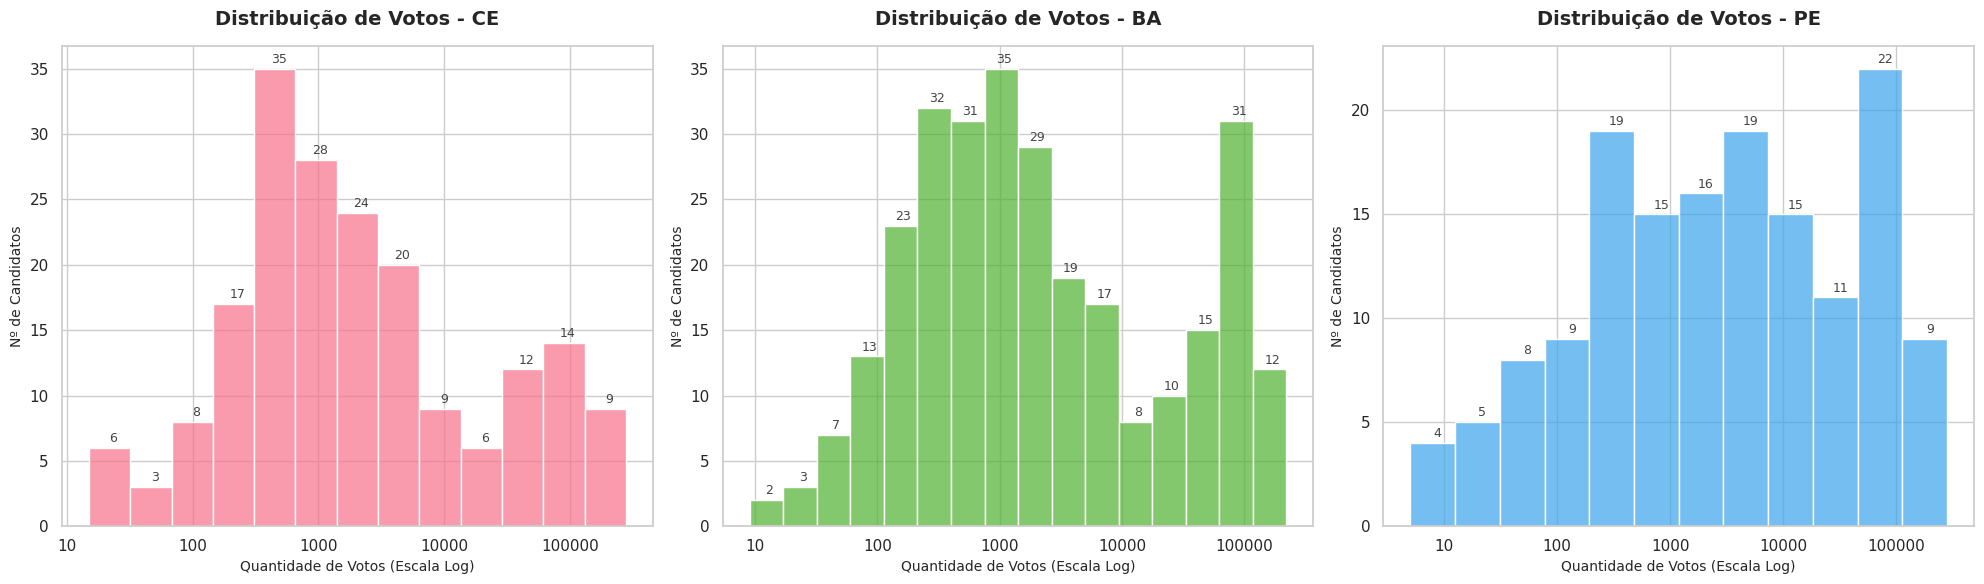

In [20]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']
state_colors = sns.color_palette('husl', n_colors=len(SELECTED_STATES))

fig, axs = plt.subplots(1, len(SELECTED_STATES), figsize=(20, 6))

for i, state in enumerate(SELECTED_STATES):
    subset_plot = df_elections.query(f'State == "{state}" and Votes > 0')
    num_bins = int(sqrt(subset_plot.shape[0])) if not subset_plot.empty else 10
    sns.histplot(
        data=subset_plot,
        x='Votes',
        color=state_colors[i],
        alpha=0.7,
        bins=num_bins,
        edgecolor="white",
        log_scale=True,
        stat="count",
        linewidth=1,
        ax=axs[i]
    )
    
    axs[i].set_title(f'Distribuição de Votos - {state}', fontsize=14, fontweight='bold', pad=15)
    axs[i].set_xlabel('Quantidade de Votos (Escala Log)', fontsize=10)
    axs[i].set_ylabel('Nº de Candidatos', fontsize=10)
    axs[i].xaxis.set_major_formatter(ScalarFormatter())
    axs[i].ticklabel_format(style='plain', axis='x')
    
    for container in axs[i].containers:
        axs[i].bar_label(container, padding=2, fontsize=9, color='#444444')

plt.tight_layout()
plt.show()

Os histogramas apresentam um padrão semelhante nos três estados (CE, BA e PE), evidenciando que a maior concentração de candidatos está na faixa entre 100 e 10.000 votos, indicando que a maioria possui votação intermediária, foi necessário o uso de escala logarítmica para gerar esse gráfico.

---
### Histogramas do dinheiro de campanhs por estado

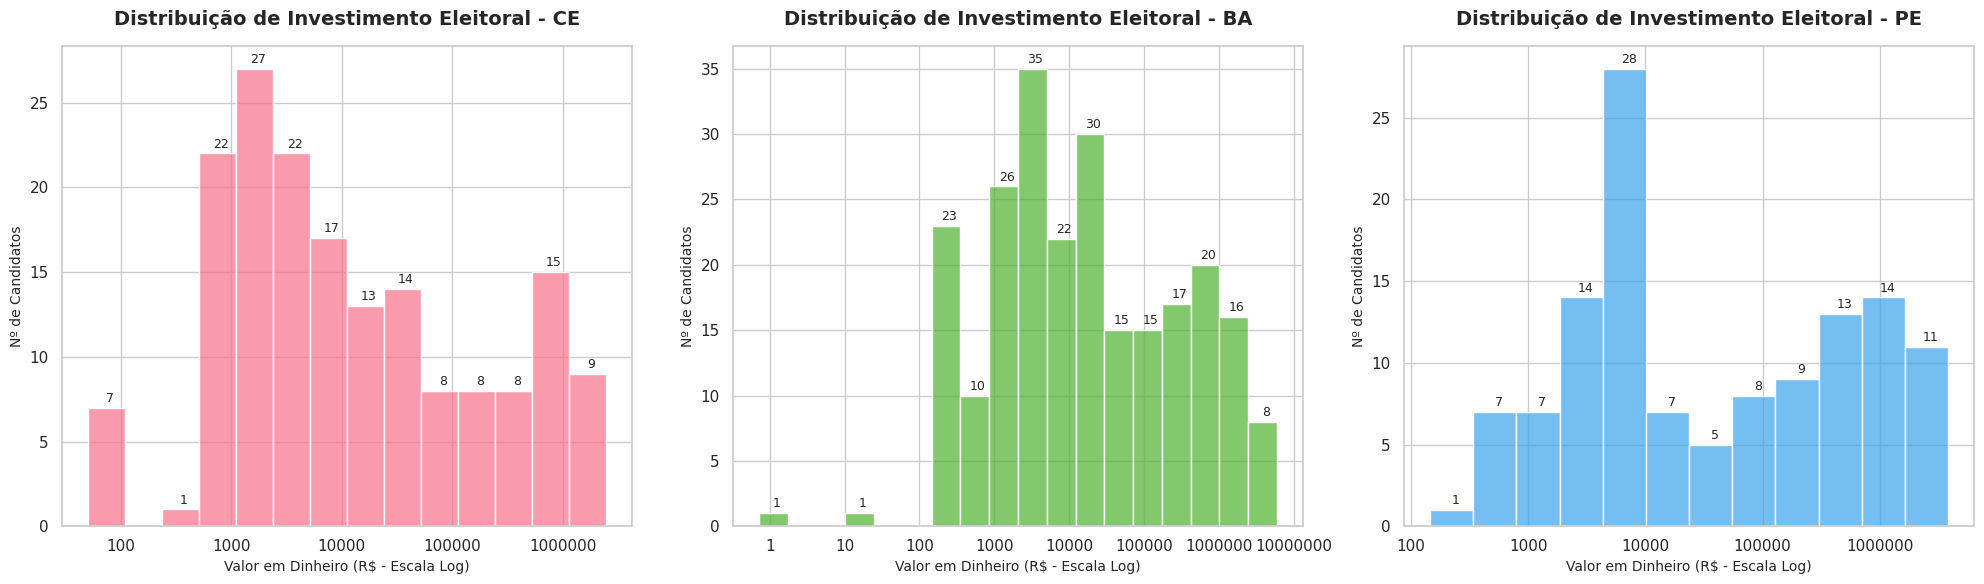

In [12]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']
state_colors = sns.color_palette('husl', n_colors=len(SELECTED_STATES))

fig, axs = plt.subplots(1, len(SELECTED_STATES), figsize=(20, 6))


for i, state in enumerate(SELECTED_STATES):
    subset_plot = df_elections.query(f'State == "{state}"')
    
    num_bins = int(sqrt(subset_plot.shape[0])) if not subset_plot.empty else 10
    
    sns.histplot(
        data=subset_plot,
        x='Money (R$ Reais)',
        color=state_colors[i],
        alpha=0.7,
        bins=num_bins,
        edgecolor="white",
        log_scale=True,
        stat="count",
        linewidth=1,
        ax=axs[i]
    )
    
    axs[i].set_title(f'Distribuição de Investimento Eleitoral - {state}', fontsize=14, fontweight='bold', pad=15)
    axs[i].set_xlabel('Valor em Dinheiro (R$ - Escala Log)', fontsize=10)
    axs[i].set_ylabel('Nº de Candidatos', fontsize=10)
    
    axs[i].xaxis.set_major_formatter(ScalarFormatter())
    axs[i].ticklabel_format(style='plain', axis='x')
    
    for container in axs[i].containers:
        labels = [f'{int(v):d}' if v > 0 else '' for v in container.datavalues]
        axs[i].bar_label(container, labels=labels, padding=2, fontsize=9)

plt.tight_layout()
plt.show()

Comparando os eixo **_x_** dos gráficos, o da BA tem uma maior distribuição de valores, de R$ 1.00 até R$ 1000000.00, em comparação aos demais além de ter uma maior concentração de valores entre R$ 1000 e 10000, entretanto PE tem uma distribuição mais densa, não havendo nenhum resultado abaixo de R$ 100.00.

---
### Gráfico de dispersão entre dinheiro e votos

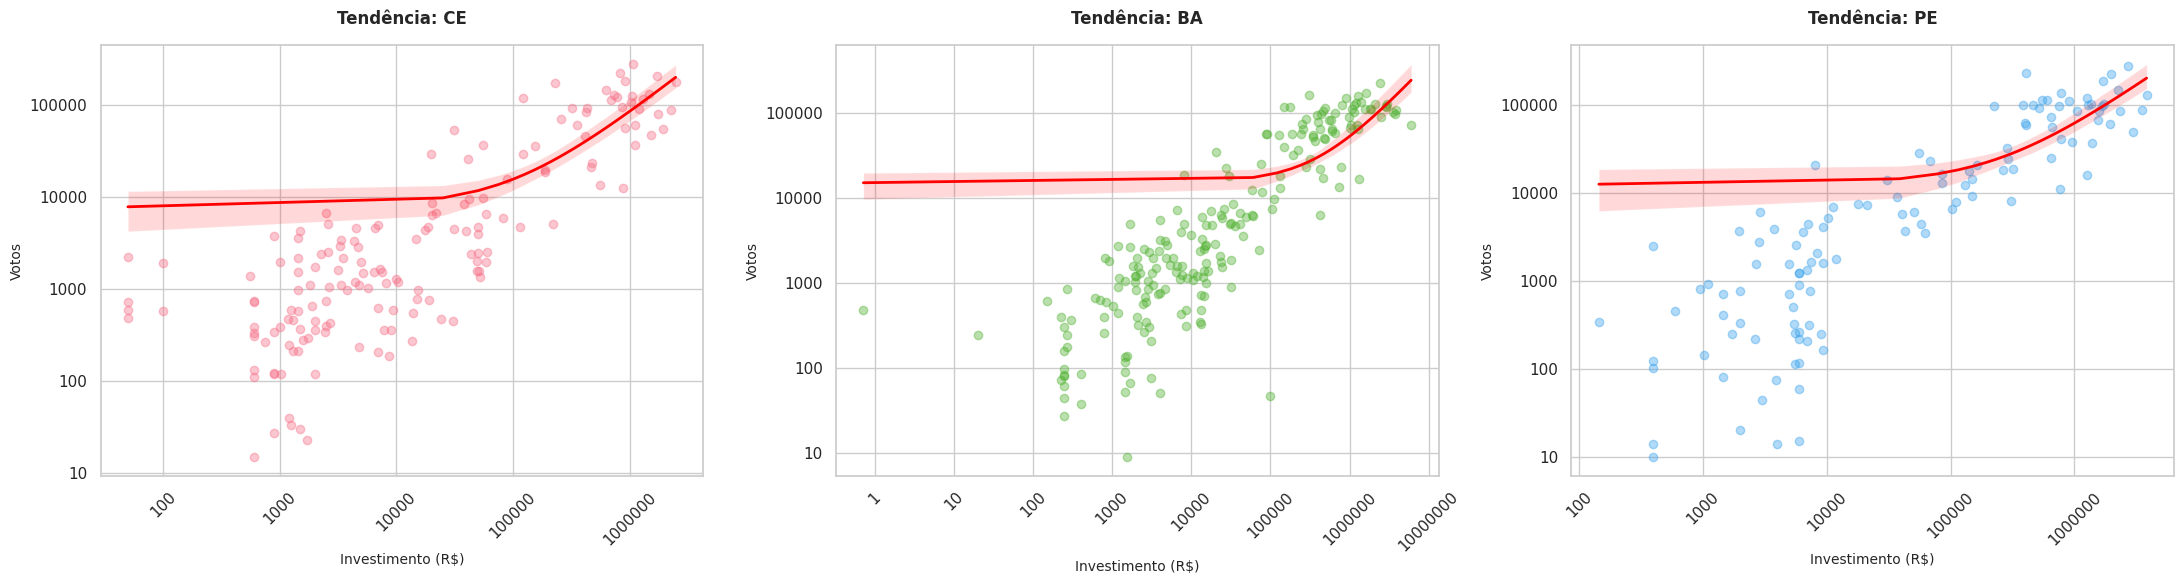

In [25]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']
state_colors = sns.color_palette('husl', n_colors=len(SELECTED_STATES))

fig, axs = plt.subplots(1, len(SELECTED_STATES), figsize=(22, 6))
axs = np.atleast_1d(axs)

for i, state in enumerate(SELECTED_STATES):
    subset = df_elections.query(f'State == "{state}" and `Money (R$ Reais)` > 0 and Votes > 0').copy()
    
    sns.regplot(
        data=subset,
        x='Money (R$ Reais)',
        y='Votes',
        ax=axs[i],
        scatter_kws={'alpha': 0.4, 'color': state_colors[i]},
        line_kws={'color': 'red', 'linewidth': 2}
    )
    
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    
    for axis in [axs[i].xaxis, axs[i].yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        formatter.set_useOffset(False)
        axis.set_major_formatter(formatter)
    
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].set_title(f'Tendência: {state}', fontsize=12, fontweight='bold', pad=15)
    axs[i].set_xlabel('Investimento (R$)', fontsize=10)
    axs[i].set_ylabel('Votos', fontsize=10)

plt.tight_layout()
plt.show()

A correlação é positiva e moderada. Embora o aumento do investimento tenda a gerar mais votos, a alta dispersão dos pontos (especialmente em investimentos baixos) mostra que outros fatores políticos e sociais também influenciam fortemente o resultado, não havendo uma concentração rígida sobre a linha de tendência.

---
### Coeficiente de correlação de Pearson entre dinheiro e votos em cada estado

In [27]:
correlacoes = []

for state in SELECTED_STATES:
    subset = df_elections.query(f'State == "{state}"').dropna(subset=['Money (R$ Reais)', 'Votes'])
    subset = subset[(subset['Money (R$ Reais)'] > 0) & (subset['Votes'] > 0)]
    corr_value = subset[['Money (R$ Reais)', 'Votes']].corr().iloc[0, 1]
    
    correlacoes.append({
        'Estado': state,
        'Correlação (R)': round(corr_value, 4),
        'Amostra (N)': subset.shape[0] 
    })

df_corr_final = pd.DataFrame(correlacoes).set_index('Estado')
df_corr_final

,Correlação (R),Amostra (N)
Estado,,
CE,0.7264,162
BA,0.6742,212
PE,0.7053,119


A tabela mostra o que foi comprovado no gráfico anterior, uma correlação ositiva e moderada. Sendo que é notória a maior correlação presente no estado do CE, mostrando que nele o dinheiro gasto na campanha consegue influenciar de maneira mais precisa na quantidade votos.

---
### Medidas de tendência central e dispersão por estado de dinheiro e votos

In [38]:
df_resumo_uf = df_elections.query(f"State in {SELECTED_STATES}").groupby('State')[['Votes', 'Money (R$ Reais)']].describe()
df_resumo_uf = df_resumo_uf.rename(columns={
    '25%': 'Q1 (25%)',
    '50%': 'Mediana (Q2)',
    '75%': 'Q3 (75%)'
}, level=1)

display(df_resumo_uf)

Votes                                                                  \
       count          mean           std  min Q1 (25%) Mediana (Q2) Q3 (75%)   
State                                                                          
BA     329.0  18183.498480  37929.692251  0.0    174.0        988.0   6268.0   
CE     201.0  19912.895522  45729.122601  0.0    355.0       1184.0   6327.0   
PE     159.0  25969.477987  49398.973115  0.0    288.0       2542.0  20970.0   

                Money (R$ Reais)                                              \
            max            count           mean            std  min Q1 (25%)   
State                                                                          
BA     222164.0            329.0  220278.106201  652156.463886  0.0     0.00   
CE     277774.0            201.0  173327.914577  424413.143407  0.0   892.36   
PE     283567.0            159.0  323947.652075  690866.481990  0.0   400.00   

                                            
      Mediana (Q2)    Q3 (75%)         max  
State                                       
BA         2651.36   41748.520  5979037.10  
CE         3748.40   50000.000  2476971.70  
PE         6390.00  276390.535  3823108.01

É notória a disparidade tanto no investimento na campanha quanto na quantidade de votos, evidenciada por desvios padrão que superam as próprias médias, o que indica uma distribuição de recursos e votos extremamente desigual.